# EmbedLab — Module 1: Supervised Contrastive Learning\n\n**Status: work in progress.** This notebook is the running explainer for Module 1 (Siamese + NT-Xent contrastive fine-tuning on STS-B). It is built incrementally alongside the implementation — right now it covers data preparation and the base encoder's forward pass; training, loss curves, baselines, and the STS-B/UMAP results will be added as those pieces land.\n\n**Research question:** how much does contrastive fine-tuning move the embedding space relative to frozen BERT?\n\nSee the [project README](../README.md) for the full three-module arc (contrastive → JEPA-inspired self-supervised → RAG retrieval benchmark)."


## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import torch

from data.prepare import load_config, prepare_sts_b
from models.encoder import TextEncoder

%matplotlib inline
pd.set_option("display.max_colwidth", 80)

## 1. Data: STS-B

STS-B (Semantic Textual Similarity Benchmark) gives sentence pairs with a human-annotated similarity score from 0 (unrelated) to 5 (semantically equivalent). We load it via `data/prepare.py`, which:

- downloads `mteb/stsbenchmark-sts` (this variant has real, non-hidden test labels, unlike GLUE's STS-B test split)
- binarizes each pair into a contrastive `label`: `1` (positive) if `score >= positive_threshold`, `0` (negative) if `score <= negative_threshold`, `-1` for the ambiguous middle band (excluded from pair-based contrastive training, kept for Spearman correlation eval since that uses the raw continuous `score`)

Same loading function the training script will use — no separate eval-only path.

### Choosing the thresholds

An earlier pass used `positive_threshold=4.0` / `negative_threshold=1.0`, which only kept 1406/5749 (24%) of the train split as usable positive pairs — the rest got dropped as "ambiguous." Manual inspection of the dropped rows showed pairs like *"A man is playing a large flute."* vs *"A man is playing a flute."* (score 3.8) being excluded even though they're clearly paraphrases — 4.0 was too strict. The sweep below shows how pair counts respond to both thresholds before settling on a value.

In [2]:
from datasets import load_dataset

config = load_config(ROOT / "configs" / "default.yaml")
raw_train = load_dataset(config["data"]["sts_b_dataset"], cache_dir=str(ROOT / config["data"]["cache_dir"]))["train"].to_pandas()

rows = []
for pos_thr in [4.5, 4.0, 3.5, 3.0]:
    for neg_thr in [1.0, 1.5, 2.0, 2.5]:
        n_pos = (raw_train["score"] >= pos_thr).sum()
        n_neg = (raw_train["score"] <= neg_thr).sum()
        rows.append({
            "positive_threshold": pos_thr,
            "negative_threshold": neg_thr,
            "n_positive": n_pos,
            "n_negative": n_neg,
            "n_excluded": len(raw_train) - n_pos - n_neg,
            "pct_usable": round(100 * (n_pos + n_neg) / len(raw_train), 1),
        })

sweep_df = pd.DataFrame(rows)
sweep_df

,positive_threshold,negative_threshold,n_positive,n_negative,n_excluded,pct_usable
0,4.5,1.0,628,1103,4018,30.1
1,4.5,1.5,628,1450,3671,36.1
2,4.5,2.0,628,1967,3154,45.1
3,4.5,2.5,628,2364,2757,52.0
4,4.0,1.0,1406,1103,3240,43.6
5,4.0,1.5,1406,1450,2893,49.7
6,4.0,2.0,1406,1967,2376,58.7
7,4.0,2.5,1406,2364,1979,65.6
8,3.5,1.0,2063,1103,2583,55.1
9,3.5,1.5,2063,1450,2236,61.1


**Decision:** `positive_threshold=3.5`, `negative_threshold=2.0` (set in `configs/default.yaml`). This raises usable training pairs from 2509 (44%, at the old 4.0/1.0 cutoffs) to 4030 (70%) — nearly doubling positive pairs (1406 → 2063) — while still excluding the genuinely ambiguous 2.0–3.5 band. Going looser (3.0/2.5) reclaims almost all the data but starts admitting weaker positives (e.g. differing on a key detail like a count or subject), which would dilute the contrastive signal.

In [3]:
splits = prepare_sts_b(
    config["data"]["sts_b_dataset"],
    ROOT / config["data"]["cache_dir"],
    positive_threshold=config["data"]["positive_threshold"],
    negative_threshold=config["data"]["negative_threshold"],
)

for name, df in splits.items():
    n_pos = (df["label"] == 1).sum()
    n_neg = (df["label"] == 0).sum()
    n_mid = (df["label"] == -1).sum()
    print(f"{name:>10}: {len(df):5d} rows | positive={n_pos:4d} negative={n_neg:4d} ambiguous(excluded)={n_mid:4d}")

splits["train"].head()

     train:  5749 rows | positive=2063 negative=1967 ambiguous(excluded)=1719
validation:  1500 rows | positive= 404 negative= 647 ambiguous(excluded)= 449
      test:  1379 rows | positive= 479 negative= 534 ambiguous(excluded)= 366


,sentence1,sentence2,score,label
0,A plane is taking off.,An air plane is taking off.,5.00,1
1,A man is playing a large flute.,A man is playing a flute.,3.80,1
2,A man is spreading shreded cheese on a pizza.,A man is spreading shredded cheese on an uncooked pizza.,3.80,1
3,Three men are playing chess.,Two men are playing chess.,2.60,-1
4,A man is playing the cello.,A man seated is playing the cello.,4.25,1


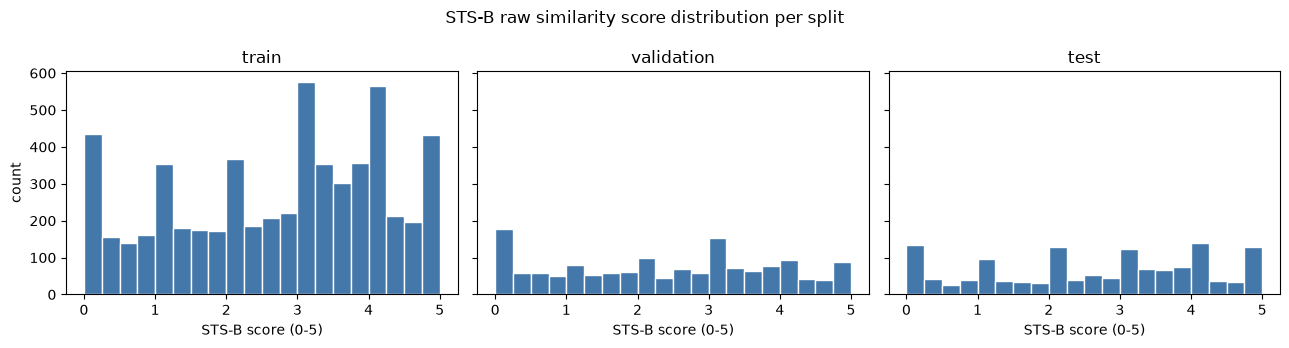

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, (name, df) in zip(axes, splits.items()):
    ax.hist(df["score"], bins=20, color="#4477AA", edgecolor="white")
    ax.set_title(name)
    ax.set_xlabel("STS-B score (0-5)")
axes[0].set_ylabel("count")
fig.suptitle("STS-B raw similarity score distribution per split")
plt.tight_layout()
plt.show()

## 2. Encoder: backbone + hand-written pooling

`models/encoder.py` wraps a pretrained `bert-base-uncased` (via `AutoModel`) with a pooling head implemented from scratch — mean-pooling over token embeddings, masked by `attention_mask`, rather than relying on sentence-transformers' `Pooling` module. This is the same encoder that the siamese wrapper (next) and the JEPA encoder (Module 2) will be built on top of.

Right now the backbone is **frozen pretrained BERT** — no fine-tuning yet. This gives us a baseline embedding space to compare against once NT-Xent contrastive training is added.

In [5]:
encoder = TextEncoder(model_name=config["model"]["backbone"], pooling=config["model"]["pooling"])

example_sentences = [
    "A man is playing a guitar.",
    "Someone is performing music on an instrument.",
    "The stock market crashed yesterday.",
]

embeddings = encoder.encode(example_sentences, max_length=config["model"]["max_length"])
print("embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings shape: torch.Size([3, 768])


In [6]:
sim_matrix = torch.nn.functional.cosine_similarity(
    embeddings.unsqueeze(1), embeddings.unsqueeze(0), dim=-1
)
sim_df = pd.DataFrame(sim_matrix.numpy(), index=example_sentences, columns=[f"s{i}" for i in range(len(example_sentences))])
sim_df.round(3)

,s0,s1,s2
A man is playing a guitar.,1.000,0.838,0.570
Someone is performing music on an instrument.,0.838,1.000,0.542
The stock market crashed yesterday.,0.570,0.542,1.000


Even with a frozen, never-fine-tuned backbone, the cosine similarity between the two paraphrase-like sentences (`s0`, `s1`) is noticeably higher than either is to the unrelated sentence (`s2`) — pretrained BERT's representation space is already somewhat semantically organized. The open question for the rest of this module: **how much does NT-Xent contrastive fine-tuning sharpen this**, and how does that compare to SBERT (trained the same way, at scale) and to the JEPA-inspired self-supervised objective in Module 2?

## What's done / what's next

**Done:**
- `data/prepare.py` — STS-B download + binarization into positive/negative/ambiguous pairs
- `models/encoder.py` — `TextEncoder` (pretrained backbone + from-scratch mean pooling), verified forward pass

**Next:**
- `losses/nt_xent.py` — NT-Xent contrastive loss
- `models/siamese.py` — siamese wrapper around `TextEncoder`
- `training/train_contrastive.py` — training loop
- `evaluation/sts_eval.py` — Spearman ρ on STS-B test set, baselines (random encoder, frozen BERT, SBERT)
- `evaluation/visualize.py` — UMAP plot of the embedding space before/after contrastive fine-tuning

This notebook will be extended with loss curves, the STS-B Spearman ρ comparison table, and UMAP plots once those pieces are in place.